# Clustering Spotify — Notebook Python

**BDD** : https://www.kaggle.com/datasets/joebeachcapital/30000-spotify-songs

## Questions à se poser
- Existe-t-il une structure latente de la musique populaire sur Spotify ?
- Peut-on regrouper les morceaux en classes homogènes ? Comment les interpréter ?
- Les genres musicaux déclarés sont-ils cohérents avec la typologie statistique ?
- La popularité est-elle associée à certaines caractéristiques musicales ?

> **Note SBM** : Le Stochastic Block Model est conservé dans le fichier R (`projet_clustering_complet.Rmd`), aucun équivalent Python aussi complet n'existe pour ce modèle.


## Librairies

In [1]:
# pip install pandas numpy matplotlib seaborn scikit-learn scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform
import warnings
warnings.filterwarnings("ignore")

# Style global des graphiques
sns.set_theme(style="whitegrid", font_scale=1.2)
PALETTE = ["#E63946", "#457B9D", "#2A9D8F", "#F4A261", "#8338EC", "#06D6A0"]


---
## Import des données et pré-traitement


In [2]:
# Import du jeu de données
data_init = pd.read_csv("Data.csv")
df = data_init.copy()

print(f"Dimensions : {df.shape}")
print("\nVariables :")
print(df.dtypes)


Dimensions : (32833, 23)

Variables :
track_id                     object
track_name                   object
track_artist                 object
track_popularity              int64
track_album_id               object
track_album_name             object
track_album_release_date     object
playlist_name                object
playlist_id                  object
playlist_genre               object
playlist_subgenre            object
danceability                float64
energy                      float64
key                           int64
loudness                    float64
mode                          int64
speechiness                 float64
acousticness                float64
instrumentalness            float64
liveness                    float64
valence                     float64
tempo                       float64
duration_ms                   int64
dtype: object


In [3]:
# ── Conversion des variables catégorielles ────────────────────────────────────
cat_cols = [
    "track_id", "track_name", "track_artist",
    "track_album_id", "track_album_name",
    "playlist_name", "playlist_id",
    "playlist_genre", "playlist_subgenre"
]
for col in cat_cols:
    df[col] = df[col].astype("category")

# Mode : 0 = mineur, 1 = majeur
df["mode"] = df["mode"].map({0: "min", 1: "maj"}).astype("category")

# Key : entier → nom de note
key_map = {0:"C", 1:"C#", 2:"D", 3:"D#", 4:"E", 5:"F",
           6:"F#", 7:"G", 8:"G#", 9:"A", 10:"A#", 11:"B"}
df["key"] = df["key"].map(key_map).astype("category")

# Duration : millisecondes → secondes
df["duration_ms"] = df["duration_ms"] / 1000
df.rename(columns={"duration_ms": "duration_s"}, inplace=True)

print("Aperçu après conversion :")
df.head(3)


Aperçu après conversion :


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_s
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,F#,-2.634,maj,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194.754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,B,-4.969,maj,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162.600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,C#,-3.432,min,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176.616


In [4]:
# ── Résumé statistique ────────────────────────────────────────────────────────
df.describe()


,track_popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_s
count,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000
mean,42.477081,0.654850,0.698619,-6.719499,0.107068,0.175334,0.084747,0.190176,0.510561,120.881132,225.799812
std,24.984074,0.145085,0.180910,2.988436,0.101314,0.219633,0.224230,0.154317,0.233146,26.903624,59.834006
min,0.000000,0.000000,0.000175,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
25%,24.000000,0.563000,0.581000,-8.171000,0.041000,0.015100,0.000000,0.092700,0.331000,99.960000,187.819000
50%,45.000000,0.672000,0.721000,-6.166000,0.062500,0.080400,0.000016,0.127000,0.512000,121.984000,216.000000
75%,62.000000,0.761000,0.840000,-4.645000,0.132000,0.255000,0.004830,0.248000,0.693000,133.918000,253.585000
max,100.000000,0.983000,1.000000,1.275000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517.810000


In [5]:
# ── Valeurs manquantes ────────────────────────────────────────────────────────
missing = df.isnull().sum()
print("Valeurs manquantes par colonne :")
print(missing[missing > 0] if missing.any() else "Aucune valeur manquante.")

# ── Séparation quali / quanti ─────────────────────────────────────────────────
df_quali  = df.select_dtypes(include="category")
df_quanti = df.select_dtypes(include="number")

print(f"\nVariables quantitatives ({df_quanti.shape[1]}) : {list(df_quanti.columns)}")


Valeurs manquantes par colonne :
track_name          5
track_artist        5
track_album_name    5
dtype: int64

Variables quantitatives (11) : ['track_popularity', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_s']


In [6]:
# ── Centrage-réduction (obligatoire pour la plupart des méthodes) ─────────────
scaler     = StandardScaler()
data_scaled = scaler.fit_transform(df_quanti)

print(f"data_scaled : {data_scaled.shape}  |  moyenne ≈ {data_scaled.mean():.2e}  |  std ≈ {data_scaled.std():.4f}")


data_scaled : (32833, 11)  |  moyenne ≈ -1.07e-17  |  std ≈ 1.0000


---
# I. Distance-based methods

## 1. K-means

L'algorithme K-means partitionne les données en `k` groupes en minimisant l'inertie intra-classe (somme des distances au carré entre chaque point et le centroïde de son cluster). L'algorithme alterne : (1) affectation de chaque point au centroïde le plus proche, (2) recalcul des centroïdes, jusqu'à convergence.


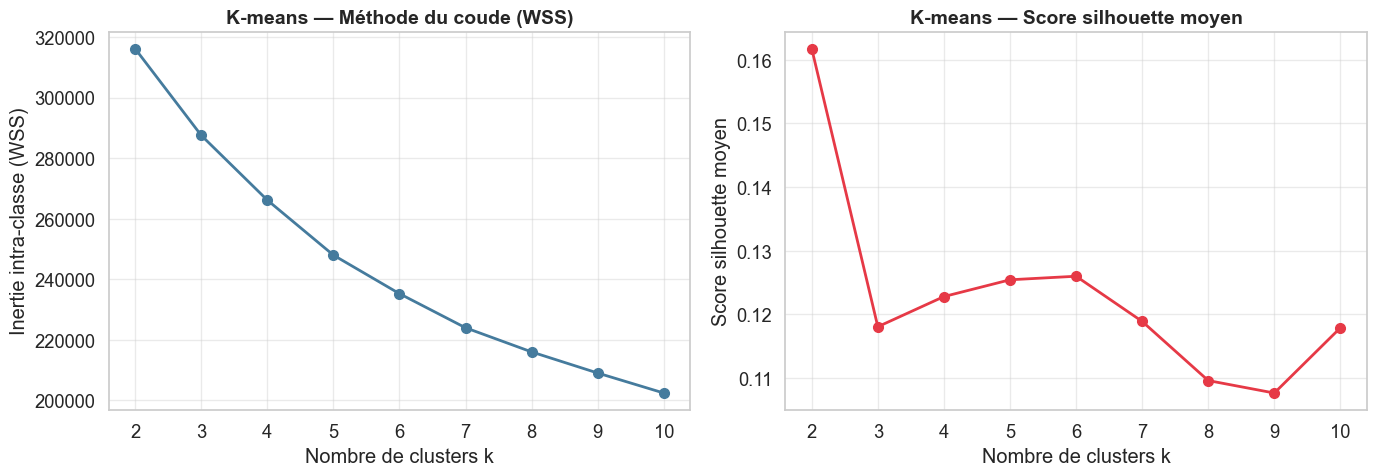

k optimal (silhouette) : 2


In [ ]:
# ── Choix de k : méthode du coude (WSS) + silhouette ─────────────────────────
K_RANGE = range(2, 11)
inertias, sil_scores = [], []

for k in K_RANGE:
    km_tmp = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km_tmp.fit_predict(data_scaled)
    inertias.append(km_tmp.inertia_)
    sil_scores.append(silhouette_score(data_scaled, labels, sample_size=5000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coude WSS
axes[0].plot(list(K_RANGE), inertias, "o-", color="#457B9D", linewidth=2, markersize=7)
axes[0].set_title("K-means — Méthode du coude (WSS)", fontweight="bold", fontsize=14)
axes[0].set_xlabel("Nombre de clusters k")
axes[0].set_ylabel("Inertie intra-classe (WSS)")
axes[0].grid(True, alpha=0.4)

# Silhouette
axes[1].plot(list(K_RANGE), sil_scores, "o-", color="#E63946", linewidth=2, markersize=7)
axes[1].set_title("K-means — Score silhouette moyen", fontweight="bold", fontsize=14)
axes[1].set_xlabel("Nombre de clusters k")
axes[1].set_ylabel("Score silhouette moyen")
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

k_optimal = int(np.argmax(sil_scores)) + 2   # +2 car K_RANGE commence à 2
print(f"k optimal (silhouette) : {k_optimal}")


In [8]:
# ── Ajustement K-means ────────────────────────────────────────────────────────
# n_init=25 : 25 initialisations aléatoires, la meilleure est retenue
# max_iter=300 : nombre maximal d'itérations

k_optimal = 2   # à ajuster d'après les graphiques ci-dessus

km = KMeans(n_clusters=k_optimal, n_init=25, max_iter=300, random_state=42)
km.fit(data_scaled)
labels_km = km.labels_

print(f"Inertie intra-classe : {km.inertia_:.2f}")
print(f"Taille des clusters  : {dict(zip(*np.unique(labels_km, return_counts=True)))}")


Inertie intra-classe : 316147.64
Taille des clusters  : {np.int32(0): np.int64(23113), np.int32(1): np.int64(9720)}


Score silhouette moyen : 0.1589


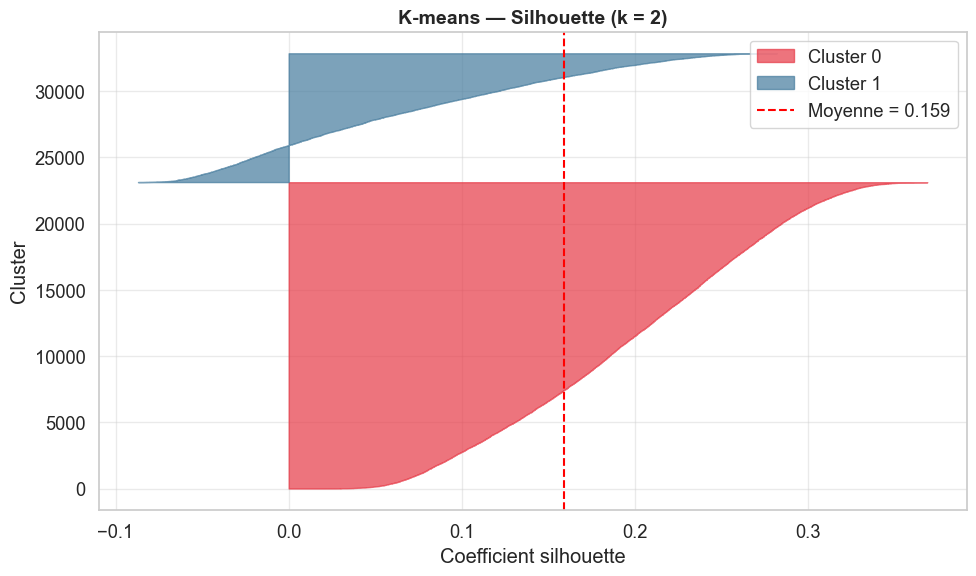

In [9]:
# ── Silhouette K-means ────────────────────────────────────────────────────────
sil_vals_km = silhouette_samples(data_scaled, labels_km)
sil_avg_km  = sil_vals_km.mean()
print(f"Score silhouette moyen : {sil_avg_km:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
for i in range(k_optimal):
    ith_sil = np.sort(sil_vals_km[labels_km == i])
    size_i  = ith_sil.shape[0]
    y_upper = y_lower + size_i
    color   = PALETTE[i % len(PALETTE)]
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil, alpha=0.7, color=color, label=f"Cluster {i}")
    y_lower = y_upper + 10

ax.axvline(sil_avg_km, color="red", linestyle="--", label=f"Moyenne = {sil_avg_km:.3f}")
ax.set_title(f"K-means — Silhouette (k = {k_optimal})", fontweight="bold", fontsize=14)
ax.set_xlabel("Coefficient silhouette")
ax.set_ylabel("Cluster")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


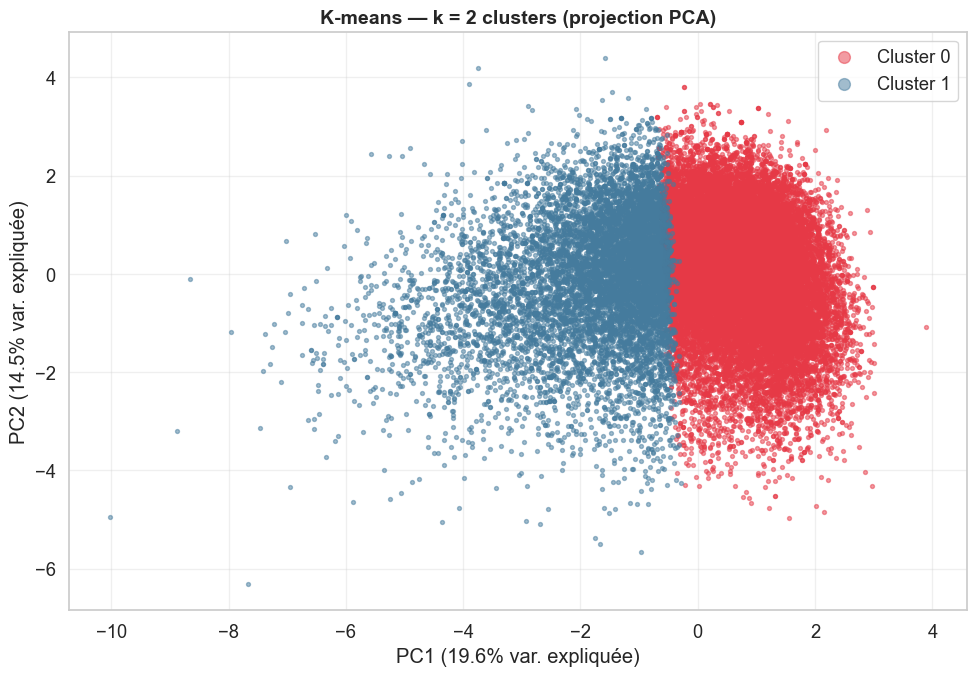

In [10]:
# ── Visualisation 2D (projection PCA) ────────────────────────────────────────
pca2 = PCA(n_components=2, random_state=42)
X_pca = pca2.fit_transform(data_scaled)
var_exp = pca2.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(10, 7))
for i in range(k_optimal):
    mask = labels_km == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               s=8, alpha=0.5, color=PALETTE[i], label=f"Cluster {i}")

ax.set_title(f"K-means — k = {k_optimal} clusters (projection PCA)", fontweight="bold", fontsize=14)
ax.set_xlabel(f"PC1 ({var_exp[0]:.1f}% var. expliquée)")
ax.set_ylabel(f"PC2 ({var_exp[1]:.1f}% var. expliquée)")
ax.legend(markerscale=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 2. CAH — Classification Ascendante Hiérarchique

La CAH construit une hiérarchie ascendante : chaque observation commence dans son propre cluster, puis les deux clusters les plus proches sont fusionnés à chaque étape. Le critère de **Ward** minimise l'augmentation de l'inertie intra-classe lors de chaque fusion.

> ⚠️ La CAH sur 30 000 observations est très coûteuse en mémoire (matrice n×n). On travaille sur un sous-échantillon de 3 000 observations.


In [11]:
# ── Sous-échantillonnage ──────────────────────────────────────────────────────
np.random.seed(42)
n_hac    = 3000
idx_hac  = np.random.choice(data_scaled.shape[0], n_hac, replace=False)
data_hac = data_scaled[idx_hac]


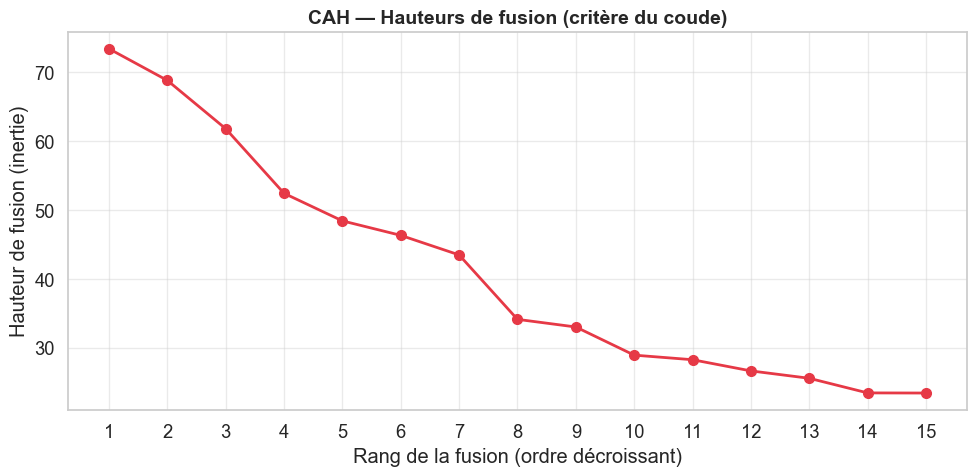

In [12]:
# ── Calcul de la liaison (Ward) et hauteurs de fusion ────────────────────────
Z = linkage(data_hac, method="ward", metric="euclidean")

# Les 15 dernières hauteurs de fusion (ordre décroissant)
hauteurs = sorted(Z[:, 2], reverse=True)[:15]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, 16), hauteurs, "o-", color="#E63946", linewidth=2, markersize=7)
ax.set_title("CAH — Hauteurs de fusion (critère du coude)", fontweight="bold", fontsize=14)
ax.set_xlabel("Rang de la fusion (ordre décroissant)")
ax.set_ylabel("Hauteur de fusion (inertie)")
ax.set_xticks(range(1, 16))
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


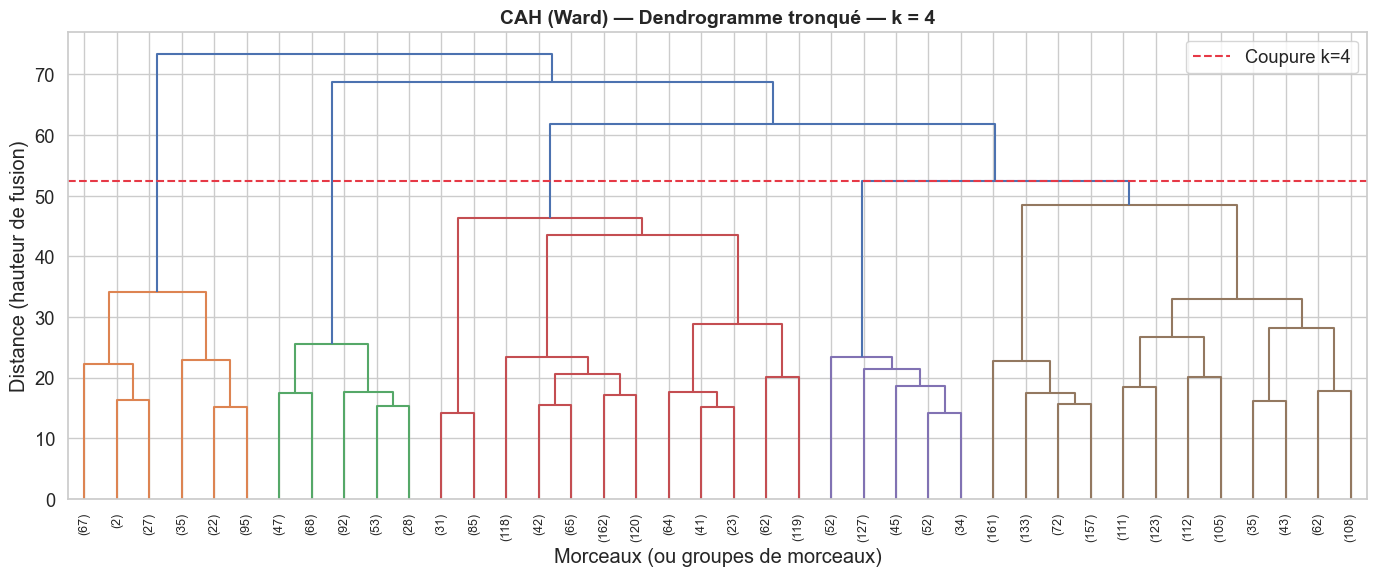

In [13]:
# ── Dendrogramme (tronqué pour lisibilité) ────────────────────────────────────
k_hac = 4   # à ajuster d'après le graphe ci-dessus

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z,
           truncate_mode="lastp",   # afficher seulement les p dernières fusions
           p=40,
           leaf_rotation=90,
           leaf_font_size=9,
           color_threshold=Z[-k_hac, 2],
           ax=ax)
ax.set_title(f"CAH (Ward) — Dendrogramme tronqué — k = {k_hac}", fontweight="bold", fontsize=14)
ax.set_xlabel("Morceaux (ou groupes de morceaux)")
ax.set_ylabel("Distance (hauteur de fusion)")
ax.axhline(Z[-k_hac, 2], color="#E63946", linestyle="--", linewidth=1.5, label=f"Coupure k={k_hac}")
ax.legend()
plt.tight_layout()
plt.show()


Score silhouette moyen CAH : 0.0914
Taille des clusters        : {np.int32(0): np.int64(248), np.int32(1): np.int64(288), np.int32(2): np.int64(932), np.int32(3): np.int64(1532)}


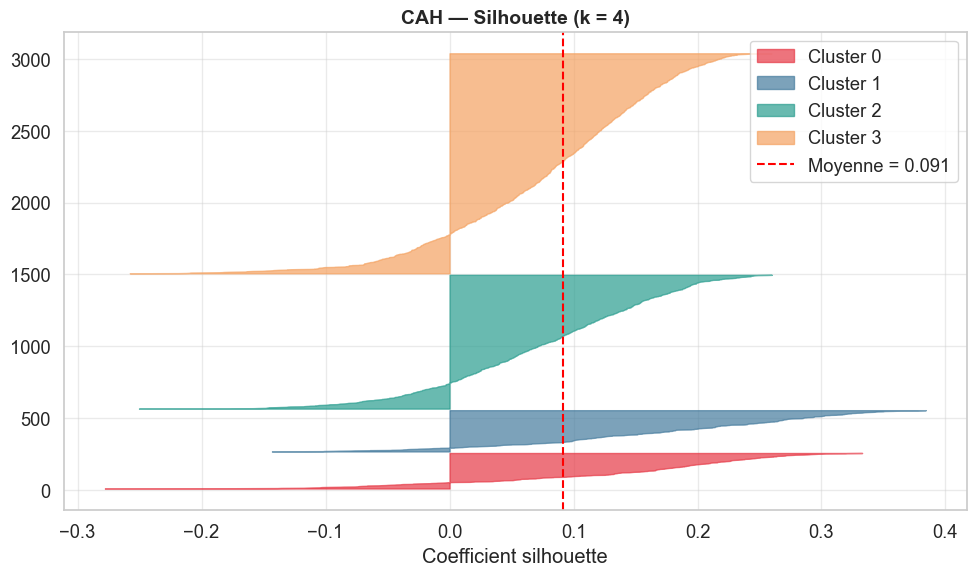

In [14]:
# ── Découpe de l'arbre et silhouette ─────────────────────────────────────────
clusters_hac = fcluster(Z, t=k_hac, criterion="maxclust") - 1  # labels 0-based

sil_vals_hac = silhouette_samples(data_hac, clusters_hac)
sil_avg_hac  = sil_vals_hac.mean()
print(f"Score silhouette moyen CAH : {sil_avg_hac:.4f}")
print(f"Taille des clusters        : {dict(zip(*np.unique(clusters_hac, return_counts=True)))}")

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
for i in range(k_hac):
    ith_sil = np.sort(sil_vals_hac[clusters_hac == i])
    size_i  = ith_sil.shape[0]
    y_upper = y_lower + size_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil,
                     alpha=0.7, color=PALETTE[i], label=f"Cluster {i}")
    y_lower = y_upper + 10

ax.axvline(sil_avg_hac, color="red", linestyle="--", label=f"Moyenne = {sil_avg_hac:.3f}")
ax.set_title(f"CAH — Silhouette (k = {k_hac})", fontweight="bold", fontsize=14)
ax.set_xlabel("Coefficient silhouette")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


In [15]:
# ── Comparaison K-means vs CAH (sur le sous-échantillon HAC) ─────────────────
labels_km_hac = labels_km[idx_hac]
ct = pd.crosstab(pd.Series(labels_km_hac, name="K-means"),
                 pd.Series(clusters_hac,  name="CAH"))
print("Table de contingence K-means vs CAH :")
print(ct)


Table de contingence K-means vs CAH :
CAH        0    1    2     3
K-means                     
0        162    6  869  1104
1         86  282   63   428


---
## 3. Spectral Clustering

Le Spectral Clustering exploite la géométrie du graphe de similarité. Il construit la matrice de similarité (noyau RBF), calcule le **Laplacien normalisé**, projette dans l'espace des vecteurs propres puis applique un k-means dans cet espace réduit. Détecte des clusters de **formes arbitraires**.


In [16]:
# ── Sous-échantillonnage (matrice n×n en mémoire) ─────────────────────────────
np.random.seed(42)
n_sc    = 2000
idx_sc  = np.random.choice(data_scaled.shape[0], n_sc, replace=False)
data_sc = data_scaled[idx_sc]


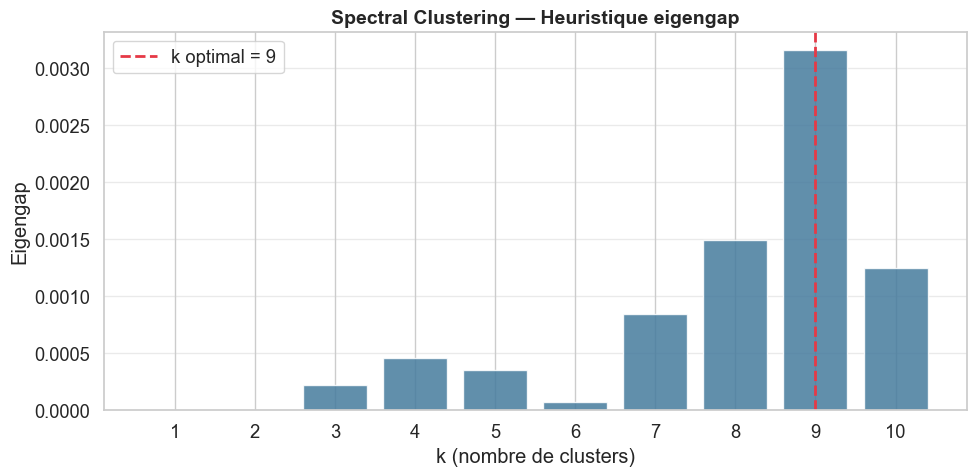

k optimal (eigengap) : 9


In [17]:
# ── Heuristique eigengap ──────────────────────────────────────────────────────
sigma_val = 1.0

# Matrice de similarité Gaussienne (RBF)
dist_sc_mat = squareform(pdist(data_sc, "euclidean"))
K_sim       = np.exp(-dist_sc_mat**2 / (2 * sigma_val**2))

# Laplacien normalisé symétrique : L = D^{-1/2} K D^{-1/2}
d           = K_sim.sum(axis=1)
D_inv_sqrt  = np.diag(1.0 / np.sqrt(d))
L_norm      = D_inv_sqrt @ K_sim @ D_inv_sqrt

# Valeurs propres (plus grandes = plus petites du Laplacien standard)
eig_vals = np.linalg.eigvalsh(L_norm)[::-1]   # tri décroissant

k_max_sc = 10
eigengap  = np.diff(eig_vals[:k_max_sc + 1])   # négatif → on cherche le min

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, k_max_sc + 1), -eigengap, color="#457B9D", alpha=0.85)
k_sc = int(np.argmax(-eigengap)) + 1
ax.axvline(k_sc, color="#E63946", linestyle="--", linewidth=2, label=f"k optimal = {k_sc}")
ax.set_title("Spectral Clustering — Heuristique eigengap", fontweight="bold", fontsize=14)
ax.set_xlabel("k (nombre de clusters)")
ax.set_ylabel("Eigengap")
ax.set_xticks(range(1, k_max_sc + 1))
ax.legend()
ax.grid(True, alpha=0.4, axis="y")
plt.tight_layout()
plt.show()
print(f"k optimal (eigengap) : {k_sc}")


In [18]:
# ── Ajustement Spectral Clustering ────────────────────────────────────────────
# affinity="rbf" : noyau gaussien
# assign_labels="kmeans" : k-means dans l'espace spectral

sc = SpectralClustering(n_clusters=k_sc,
                        affinity="rbf",
                        gamma=1.0 / (2 * sigma_val**2),
                        assign_labels="kmeans",
                        n_init=10,
                        random_state=42,
                        n_jobs=-1)
clusters_sc = sc.fit_predict(data_sc)

print(f"Taille des clusters : {dict(zip(*np.unique(clusters_sc, return_counts=True)))}")


Taille des clusters : {np.int32(0): np.int64(1911), np.int32(1): np.int64(2), np.int32(2): np.int64(4), np.int32(3): np.int64(3), np.int32(4): np.int64(5), np.int32(5): np.int64(3), np.int32(6): np.int64(31), np.int32(7): np.int64(29), np.int32(8): np.int64(12)}


Score silhouette moyen : 0.1923


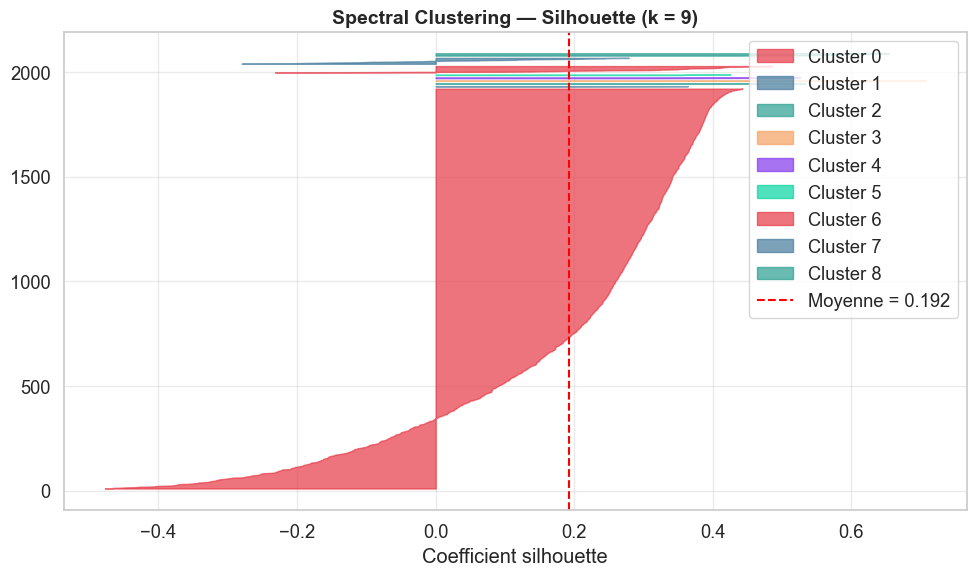

In [19]:
# ── Silhouette Spectral Clustering ───────────────────────────────────────────
sil_vals_sc = silhouette_samples(data_sc, clusters_sc)
sil_avg_sc  = sil_vals_sc.mean()
print(f"Score silhouette moyen : {sil_avg_sc:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
for i in range(k_sc):
    ith_sil = np.sort(sil_vals_sc[clusters_sc == i])
    size_i  = ith_sil.shape[0]
    y_upper = y_lower + size_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil,
                     alpha=0.7, color=PALETTE[i % len(PALETTE)], label=f"Cluster {i}")
    y_lower = y_upper + 10

ax.axvline(sil_avg_sc, color="red", linestyle="--", label=f"Moyenne = {sil_avg_sc:.3f}")
ax.set_title(f"Spectral Clustering — Silhouette (k = {k_sc})", fontweight="bold", fontsize=14)
ax.set_xlabel("Coefficient silhouette")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


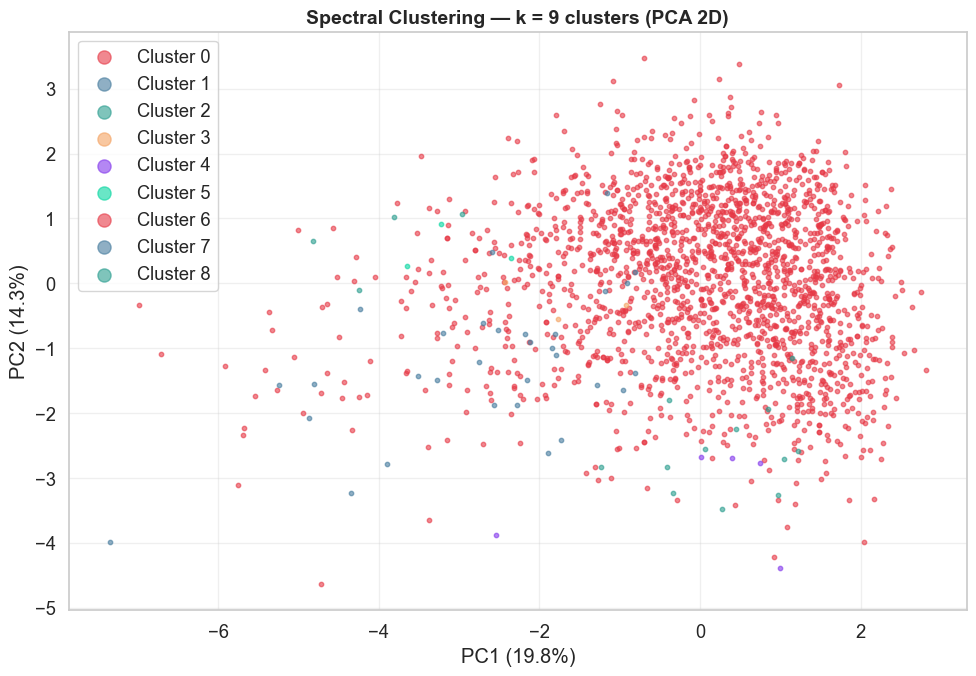

In [20]:
# ── Visualisation 2D (PCA) ────────────────────────────────────────────────────
pca_sc = PCA(n_components=2, random_state=42)
X_sc_2d = pca_sc.fit_transform(data_sc)

fig, ax = plt.subplots(figsize=(10, 7))
for i in range(k_sc):
    mask = clusters_sc == i
    ax.scatter(X_sc_2d[mask, 0], X_sc_2d[mask, 1],
               s=10, alpha=0.6, color=PALETTE[i % len(PALETTE)], label=f"Cluster {i}")

ax.set_title(f"Spectral Clustering — k = {k_sc} clusters (PCA 2D)", fontweight="bold", fontsize=14)
ax.set_xlabel(f"PC1 ({pca_sc.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca_sc.explained_variance_ratio_[1]*100:.1f}%)")
ax.legend(markerscale=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 4. DBSCAN — Density-Based Spatial Clustering of Applications with Noise

DBSCAN regroupe des points **densément connectés** sans imposer de forme géométrique. Deux paramètres : `eps` (rayon de voisinage) et `min_samples` (nombre minimal de voisins pour être un point *core*). Les points isolés sont étiquetés **bruit** (label -1). Avantage : détection automatique des outliers, pas besoin de spécifier k.


In [21]:
# ── Sous-échantillonnage ──────────────────────────────────────────────────────
np.random.seed(42)
n_db    = 3000
idx_db  = np.random.choice(data_scaled.shape[0], n_db, replace=False)
data_db = data_scaled[idx_db]


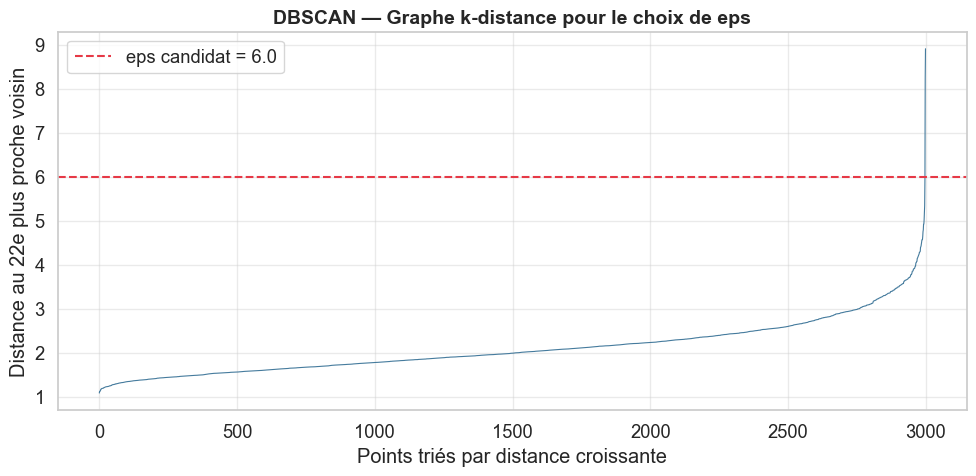

In [26]:
# ── Choix de eps : graphe k-distance ─────────────────────────────────────────
# Pour chaque point, on calcule la distance à son k-ième plus proche voisin.
# On trie et cherche le "coude" — c'est la valeur eps candidate.

min_samples_val = data_db.shape[1] * 2   # règle empirique : 2 × dimension

nbrs = NearestNeighbors(n_neighbors=min_samples_val, n_jobs=-1)
nbrs.fit(data_db)
distances, _ = nbrs.kneighbors(data_db)
k_dist = np.sort(distances[:, -1])       # distance au k-ième voisin, triée

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_dist, color="#457B9D", linewidth=0.8)
ax.axhline(6.0, color="#E63946", linestyle="--", linewidth=1.5, label="eps candidat = 6.0")
ax.set_title("DBSCAN — Graphe k-distance pour le choix de eps", fontweight="bold", fontsize=14)
ax.set_xlabel("Points triés par distance croissante")
ax.set_ylabel(f"Distance au {min_samples_val}e plus proche voisin")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


In [33]:
# ── Ajustement DBSCAN ─────────────────────────────────────────────────────────
eps_val = 6.0   # à ajuster d'après le graphe k-distance ci-dessus

db = DBSCAN(eps=eps_val,
            min_samples=min_samples_val,
            metric="euclidean",
            n_jobs=-1)
clusters_db = db.fit_predict(data_db)   # -1 = bruit

n_clusters_db = len(set(clusters_db)) - (1 if -1 in clusters_db else 0)
n_noise       = (clusters_db == -1).sum()

print(f"Nombre de clusters : {n_clusters_db}")
print(f"Points de bruit    : {n_noise} ({n_noise/n_db*100:.1f}%)")
print(f"Taille clusters    : {dict(zip(*np.unique(clusters_db, return_counts=True)))}")


Nombre de clusters : 1
Points de bruit    : 2 (0.1%)
Taille clusters    : {np.int64(-1): np.int64(2), np.int64(0): np.int64(2998)}


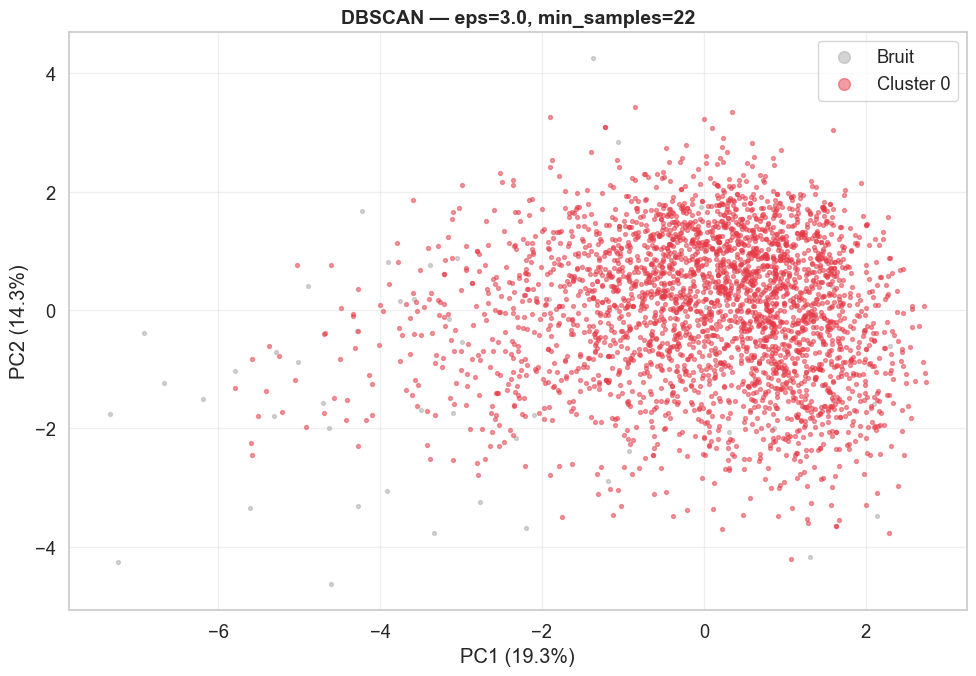

In [24]:
# ── Visualisation 2D (PCA) ────────────────────────────────────────────────────
pca_db  = PCA(n_components=2, random_state=42)
X_db_2d = pca_db.fit_transform(data_db)

unique_labels = sorted(set(clusters_db))
pal_db = ["#aaaaaa"] + PALETTE[:n_clusters_db]  # gris pour le bruit

fig, ax = plt.subplots(figsize=(10, 7))
for label, color in zip(unique_labels, pal_db):
    mask  = clusters_db == label
    lname = "Bruit" if label == -1 else f"Cluster {label}"
    ax.scatter(X_db_2d[mask, 0], X_db_2d[mask, 1],
               s=8, alpha=0.5, color=color, label=lname)

ax.set_title(f"DBSCAN — eps={eps_val}, min_samples={min_samples_val}", fontweight="bold", fontsize=14)
ax.set_xlabel(f"PC1 ({pca_db.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca_db.explained_variance_ratio_[1]*100:.1f}%)")
ax.legend(markerscale=3, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [25]:
# ── Silhouette DBSCAN (sans les points de bruit) ─────────────────────────────
mask_core = clusters_db != -1
if mask_core.sum() > 1 and len(np.unique(clusters_db[mask_core])) > 1:
    sil_vals_db = silhouette_samples(data_db[mask_core], clusters_db[mask_core])
    sil_avg_db  = sil_vals_db.mean()
    print(f"Score silhouette moyen (sans bruit) : {sil_avg_db:.4f}")
    print(f"Points classés : {mask_core.sum()} / {n_db}")

    fig, ax = plt.subplots(figsize=(10, 6))
    y_lower = 10
    labels_core = clusters_db[mask_core]
    for i, cl in enumerate(np.unique(labels_core)):
        ith_sil = np.sort(sil_vals_db[labels_core == cl])
        size_i  = ith_sil.shape[0]
        y_upper = y_lower + size_i
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil,
                         alpha=0.7, color=PALETTE[i % len(PALETTE)], label=f"Cluster {cl}")
        y_lower = y_upper + 10

    ax.axvline(sil_avg_db, color="red", linestyle="--", label=f"Moyenne = {sil_avg_db:.3f}")
    ax.set_title(f"DBSCAN — Silhouette (sans bruit, eps={eps_val})", fontweight="bold", fontsize=14)
    ax.set_xlabel("Coefficient silhouette")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()
else:
    print("Silhouette non calculable : trop peu de clusters ou tous les points sont du bruit.")
    print("Essayez d'augmenter eps ou de réduire min_samples.")
    sil_avg_db = np.nan


Silhouette non calculable : trop peu de clusters ou tous les points sont du bruit.
Essayez d'augmenter eps ou de réduire min_samples.


---
# II. Model-based methods

## 1. GMM — Modèles de Mélange Gaussien

Un GMM modélise les données comme un mélange de G lois gaussiennes multivariées. Chaque observation possède une **probabilité d'appartenance** à chaque composante (*clustering mou*). L'inférence est réalisée par l'algorithme **EM**. La sélection du modèle (structure de covariance + G) se fait via le **BIC**.


In [34]:
# ── Sous-échantillonnage ──────────────────────────────────────────────────────
np.random.seed(42)
n_gmm    = 3000
idx_gmm  = np.random.choice(data_scaled.shape[0], n_gmm, replace=False)
data_gmm = data_scaled[idx_gmm]


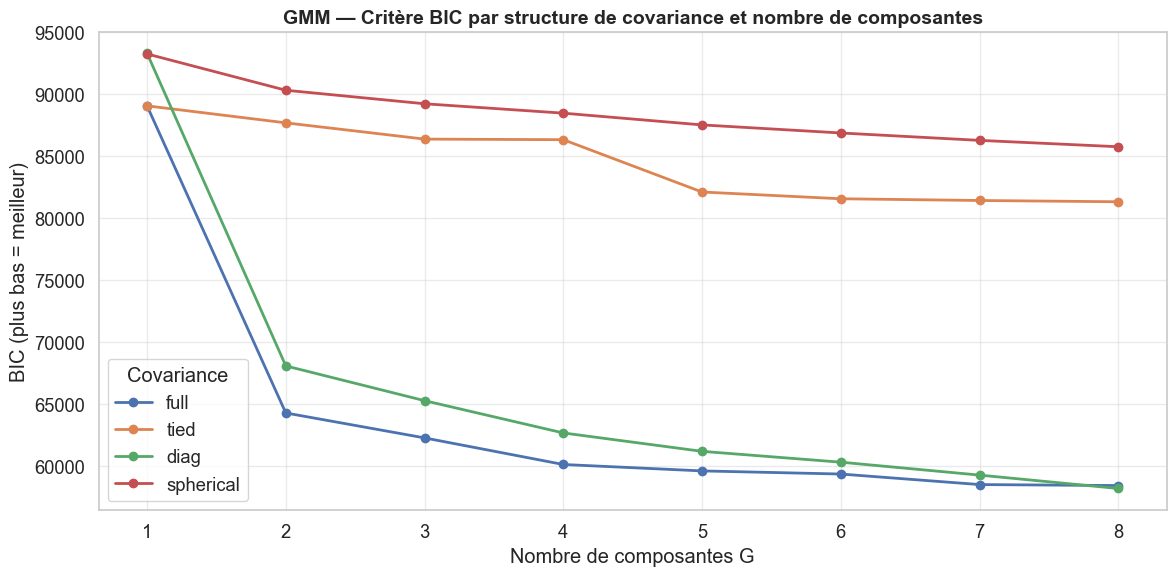

Modèle optimal : covariance='diag', G=8


In [35]:
# ── Sélection de G et de la structure de covariance via BIC ──────────────────
# covariance_type :
#   "full"  : chaque composante a sa propre matrice de covariance complète (≈ VVV en R)
#   "tied"  : toutes les composantes partagent la même matrice (≈ EEE)
#   "diag"  : matrices diagonales (axes alignés, variances libres)
#   "spherical" : variance scalaire par composante

G_range   = range(1, 9)
cov_types = ["full", "tied", "diag", "spherical"]
bic_results = {}

for cov in cov_types:
    bics = []
    for g in G_range:
        gmm_tmp = GaussianMixture(n_components=g, covariance_type=cov,
                                   n_init=3, max_iter=200, random_state=42)
        gmm_tmp.fit(data_gmm)
        bics.append(gmm_tmp.bic(data_gmm))
    bic_results[cov] = bics

fig, ax = plt.subplots(figsize=(12, 6))
for cov, bics in bic_results.items():
    ax.plot(list(G_range), bics, "o-", label=cov, linewidth=2, markersize=6)

ax.set_title("GMM — Critère BIC par structure de covariance et nombre de composantes",
             fontweight="bold", fontsize=14)
ax.set_xlabel("Nombre de composantes G")
ax.set_ylabel("BIC (plus bas = meilleur)")
ax.set_xticks(list(G_range))
ax.legend(title="Covariance")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# Modèle optimal : BIC minimal
best_cov = min(bic_results, key=lambda c: min(bic_results[c]))
best_g   = int(np.argmin(bic_results[best_cov])) + 1
print(f"Modèle optimal : covariance='{best_cov}', G={best_g}")


In [36]:
# ── Ajustement du modèle optimal ─────────────────────────────────────────────
gmm = GaussianMixture(n_components=best_g,
                      covariance_type=best_cov,
                      n_init=5, max_iter=300, random_state=42)
gmm.fit(data_gmm)

clusters_gmm  = gmm.predict(data_gmm)
proba_gmm     = gmm.predict_proba(data_gmm)
uncertainty   = 1 - proba_gmm.max(axis=1)   # incertitude = 1 - proba max

print(f"BIC : {gmm.bic(data_gmm):.2f}")
print(f"Log-vraisemblance : {gmm.score(data_gmm):.4f}")
print(f"Taille des composantes : {dict(zip(*np.unique(clusters_gmm, return_counts=True)))}")
print(f"Incertitude moyenne    : {uncertainty.mean():.4f}")


BIC : 58210.55
Log-vraisemblance : -9.4576
Taille des composantes : {np.int64(0): np.int64(284), np.int64(1): np.int64(142), np.int64(2): np.int64(236), np.int64(3): np.int64(290), np.int64(4): np.int64(693), np.int64(5): np.int64(867), np.int64(6): np.int64(267), np.int64(7): np.int64(221)}
Incertitude moyenne    : 0.0838


Score silhouette moyen : -0.0101


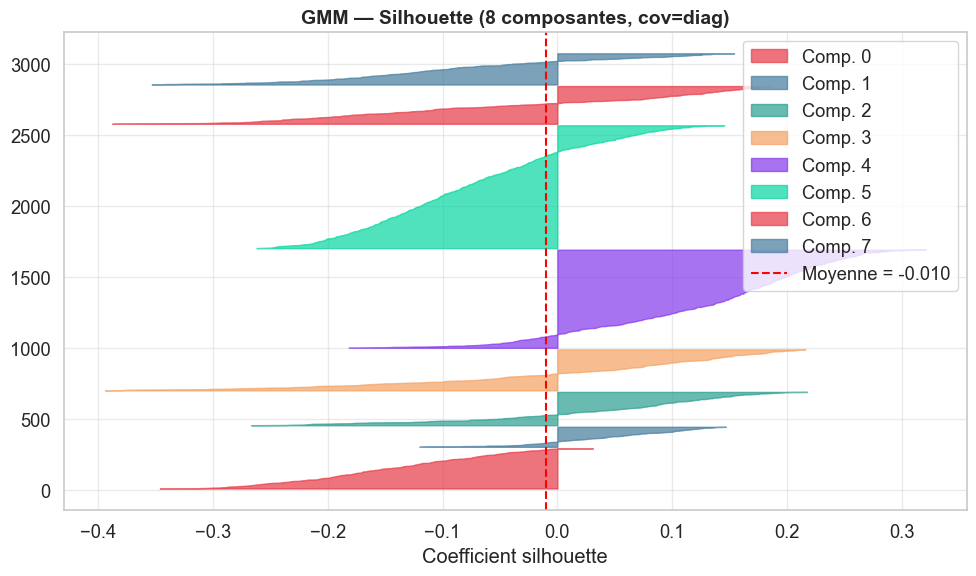

In [37]:
# ── Silhouette GMM ────────────────────────────────────────────────────────────
sil_vals_gmm = silhouette_samples(data_gmm, clusters_gmm)
sil_avg_gmm  = sil_vals_gmm.mean()
print(f"Score silhouette moyen : {sil_avg_gmm:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
for i in range(best_g):
    ith_sil = np.sort(sil_vals_gmm[clusters_gmm == i])
    size_i  = ith_sil.shape[0]
    y_upper = y_lower + size_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil,
                     alpha=0.7, color=PALETTE[i % len(PALETTE)], label=f"Comp. {i}")
    y_lower = y_upper + 10

ax.axvline(sil_avg_gmm, color="red", linestyle="--", label=f"Moyenne = {sil_avg_gmm:.3f}")
ax.set_title(f"GMM — Silhouette ({best_g} composantes, cov={best_cov})", fontweight="bold", fontsize=14)
ax.set_xlabel("Coefficient silhouette")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


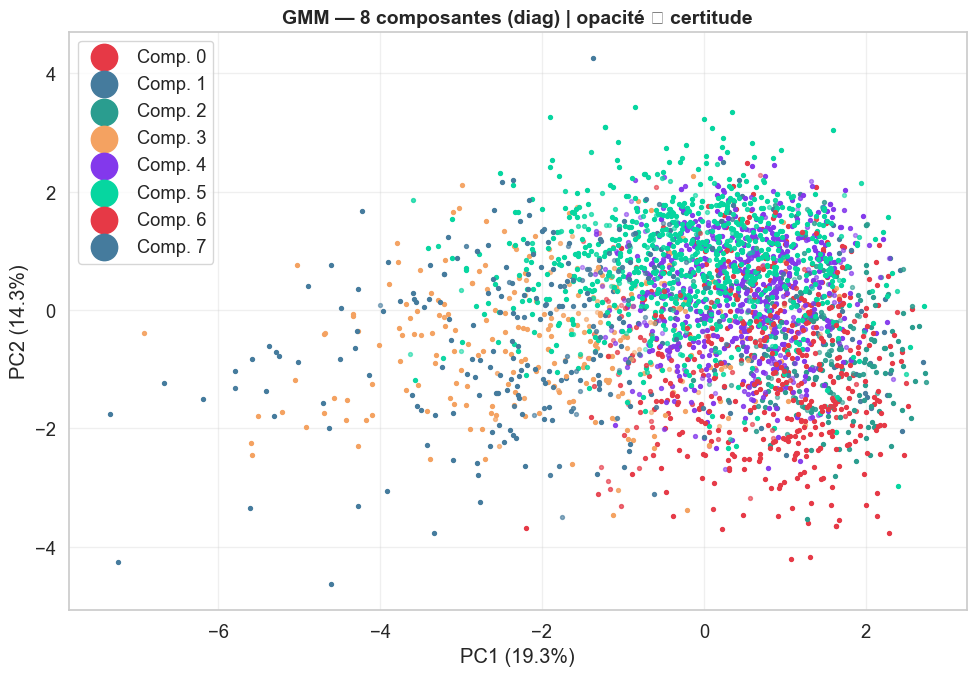

In [38]:
# ── Visualisation 2D (PCA) — opacité ∝ certitude ─────────────────────────────
pca_gmm  = PCA(n_components=2, random_state=42)
X_gmm_2d = pca_gmm.fit_transform(data_gmm)

fig, ax = plt.subplots(figsize=(10, 7))
for i in range(best_g):
    mask    = clusters_gmm == i
    alphas  = np.clip(1 - uncertainty[mask], 0.1, 1.0)
    color   = PALETTE[i % len(PALETTE)]
    # scatter avec alpha variable (matplotlib ne supporte pas alpha array directement)
    for xi, yi, ai in zip(X_gmm_2d[mask, 0], X_gmm_2d[mask, 1], alphas):
        ax.scatter(xi, yi, s=8, color=color, alpha=float(ai))
    ax.scatter([], [], color=color, label=f"Comp. {i}", s=40)  # légende

ax.set_title(f"GMM — {best_g} composantes ({best_cov}) | opacité ∝ certitude",
             fontweight="bold", fontsize=14)
ax.set_xlabel(f"PC1 ({pca_gmm.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca_gmm.explained_variance_ratio_[1]*100:.1f}%)")
ax.legend(markerscale=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 2. SBM — Stochastic Block Model

> **Le SBM est conservé dans le fichier R** (`projet_clustering_complet.Rmd`).
> Aucun package Python ne propose un équivalent aussi complet du package `sbm` de R
> (sélection automatique du nombre de blocs via ICL, EM variationnel pour graphes bernoulli).
>
> Pour exécuter cette partie, ouvrir le `.Rmd` et lancer la section **II. 2. SBM**.


---
# III. Synthèse comparative des méthodes


In [ ]:
# ── Récapitulatif des scores silhouette ───────────────────────────────────────
methodes = [
    f"K-means (k={k_optimal})",
    f"CAH Ward (k={k_hac})",
    f"Spectral (k={k_sc})",
    f"DBSCAN (eps={eps_val})",
    f"GMM ({best_cov}, G={best_g})",
]
scores = [sil_avg_km, sil_avg_hac, sil_avg_sc, sil_avg_db, sil_avg_gmm]
types  = ["Distance", "Distance", "Distance (Graph)", "Densité", "Model-based"]

df_syn = pd.DataFrame({"Méthode": methodes, "Silhouette": scores, "Type": types})
df_syn["Silhouette"] = df_syn["Silhouette"].round(4)
print(df_syn.sort_values("Silhouette", ascending=False).to_string(index=False))


In [ ]:
# ── Graphique comparatif ──────────────────────────────────────────────────────
df_plot = df_syn.dropna(subset=["Silhouette"]).sort_values("Silhouette")
palette_type = {"Distance": "#457B9D", "Distance (Graph)": "#2A9D8F",
                "Densité": "#F4A261", "Model-based": "#E63946"}

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(df_plot["Méthode"], df_plot["Silhouette"],
               color=[palette_type[t] for t in df_plot["Type"]],
               alpha=0.85, height=0.6)

for bar, val in zip(bars, df_plot["Silhouette"]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=11)

# Légende manuelle
from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=t) for t, c in palette_type.items()]
ax.legend(handles=legend_handles, title="Famille", loc="lower right")

ax.set_title("Comparaison des méthodes de clustering — Score silhouette moyen",
             fontweight="bold", fontsize=14)
ax.set_xlabel("Score silhouette moyen (plus élevé = meilleure séparation)")
ax.set_xlim(0, df_plot["Silhouette"].max() * 1.25)
ax.grid(True, alpha=0.4, axis="x")
plt.tight_layout()
plt.show()
